## Loading the Data

In [327]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from termcolor import colored

In [328]:
path= 'credit_risk_dataset.csv'
data= pd.read_csv(path)
df= data.copy()

## EDA

In [329]:
df.shape

(32581, 12)

In [330]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [331]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [332]:
df.dtypes.value_counts()

int64      5
object     4
float64    3
Name: count, dtype: int64

In [333]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [334]:
# questions to answer
# Are (Young / low income) people more likely to default.
# do bad loan_grades significantly affect the default status.
# are higher loan amount / interest rates increase the default probability.
# do people with stable jobs default less.

In [335]:
# our data studies the credit card default status of some unknown bank in an unknown location.
# no id or name in each record, some people could have taken many loans at the same time.

In [336]:
print('duplicated rows:',colored(df.duplicated().sum(),'yellow')) # 165 duplicated rows
df.drop_duplicates(inplace= True)

duplicated rows: 165


In [337]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [338]:
# segmenting the records based on unique identifier (a person)
df.duplicated(subset= ['person_age', 'person_income', 'person_home_ownership','person_emp_length',
                       'cb_person_default_on_file', 'cb_person_cred_hist_length']).sum()
# 3385 people took multiple loans at once.

3385

In [339]:
flag_identifier_cols= ['person_age', 'person_income', 'person_home_ownership','person_emp_length',
                       'cb_person_default_on_file', 'cb_person_cred_hist_length']
df['count']= df.groupby(flag_identifier_cols, dropna= False)['person_age'].transform('count')

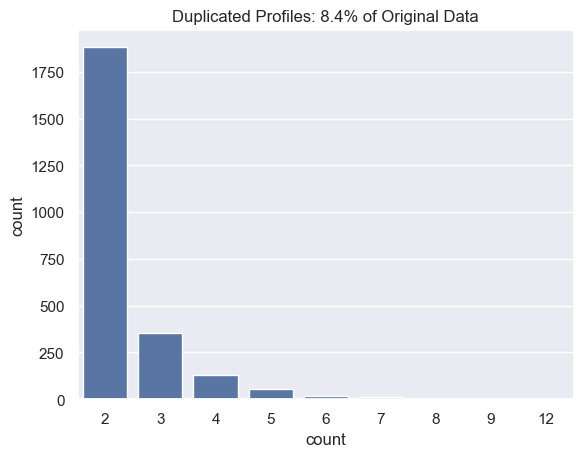

In [340]:
mask= df.duplicated(subset= flag_identifier_cols)
new_mask= df[~mask]['count'] > 1
percentage = round((len(df[~mask][new_mask]) / len(df[~mask])) * 100, 1)
plt.figure()
sns.countplot(data= df[~mask][new_mask], x= 'count')
plt.title(f'Duplicated Profiles: {percentage}% of Original Data')
plt.show()
# it appears around 8% of the records belong to people that took more than
# one loan at the same time, with around 1700 of them taking two loans at once,
# importance to keep in mind.

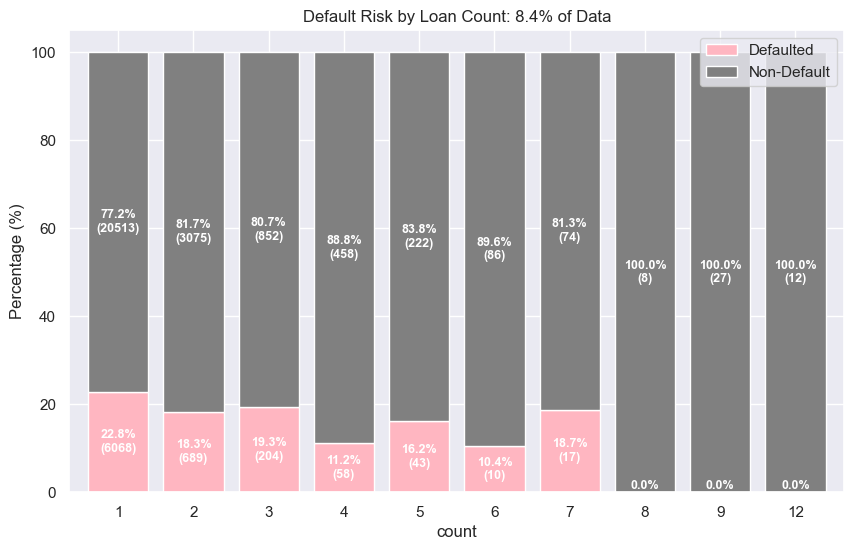

In [341]:
# 1. Prepare Dataframes (Percentages and Counts)
# We use [1, 0] to ensure Default (1) is the bottom/pink slice
pivot_pct = pd.crosstab(df['count'], df['loan_status'], normalize='index')[[1, 0]] * 100
pivot_cnt = pd.crosstab(df['count'], df['loan_status'])[[1, 0]]

plt.figure(figsize=(10, 6))
# Plotting with pink for Default (1) and grey for Non-Default (0)
pivot_pct.plot(kind='bar', stacked=True, color=['#FFB6C1', 'grey'], width=0.8, ax=plt.gca())

# 2. Add labels (Percentage + Raw Count)
for i, container in enumerate(plt.gca().containers):
    # Zip data to create 'X.X% (Count)' strings
    labels = [f'{p:.1f}%\n({c})' for p, c in zip(container.datavalues, pivot_cnt.iloc[:, i])]
    
    plt.gca().bar_label(container, labels=labels, label_type='center', 
                        color='white', fontweight='bold', fontsize=9)

plt.ylabel('Percentage (%)')
plt.title(f'Default Risk by Loan Count: {percentage}% of Data')
plt.xticks(rotation=0)
plt.legend(['Defaulted', 'Non-Default'], loc='upper right')
plt.show()

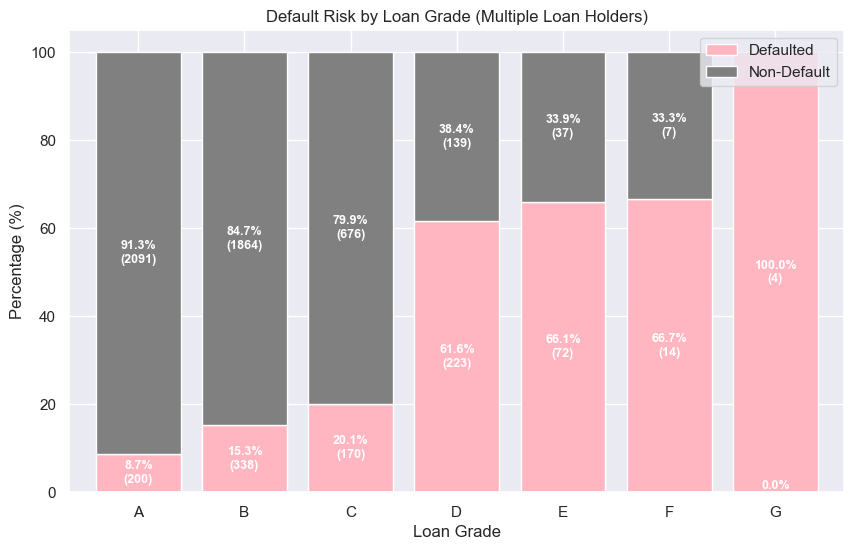

In [342]:
# 1. Filter and Create Cross-tabulation
multiple_loans_df = df[df['count'] > 1]
pivot_pct = pd.crosstab(multiple_loans_df['loan_grade'], multiple_loans_df['loan_status'], normalize='index')[[1, 0]] * 100
pivot_cnt = pd.crosstab(multiple_loans_df['loan_grade'], multiple_loans_df['loan_status'])[[1, 0]]

# 2. Plotting
plt.figure(figsize=(10, 6))
pivot_pct.plot(kind='bar', stacked=True, color=['#FFB6C1', 'grey'], width=0.8, ax=plt.gca())

# 3. Add Labels (Percentage and Raw Count)
for i, container in enumerate(plt.gca().containers):
    labels = [f'{p:.1f}%\n({c})' for p, c in zip(container.datavalues, pivot_cnt.iloc[:, i])]
    plt.gca().bar_label(container, labels=labels, label_type='center', 
                        color='white', fontweight='bold', fontsize=9)

plt.ylabel('Percentage (%)')
plt.xlabel('Loan Grade')
plt.title('Default Risk by Loan Grade (Multiple Loan Holders)')
plt.xticks(rotation=0)
plt.legend(['Defaulted', 'Non-Default'])
plt.show()

In [343]:
df[df['count'] > 1].describe().round(1)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,count
count,5835.0,5835.0,5756.0,5835.0,5285.0,5835.0,5835.0,5835.0,5835.0
mean,24.5,57825.8,4.3,8907.2,10.3,0.2,0.2,3.8,2.7
std,3.3,27757.9,3.3,5619.7,3.0,0.4,0.1,2.3,1.3
min,21.0,5000.0,0.0,700.0,5.4,0.0,0.0,2.0,2.0
25%,22.0,40000.0,2.0,5000.0,7.7,0.0,0.1,2.0,2.0
50%,24.0,52000.0,4.0,8000.0,10.4,0.0,0.2,3.0,2.0
75%,25.0,70000.0,7.0,12000.0,12.4,0.0,0.2,4.0,3.0
max,47.0,400000.0,21.0,35000.0,21.7,1.0,0.7,17.0,12.0


In [344]:
print('freq:', len(df[(df['count']>1) & (df['loan_grade'].isin(['A','B','C']))]),'\n----------------')
print(df[(df['count']>1) & (df['loan_grade'].isin(['A','B','C']))]['loan_status'].value_counts(normalize= True).round(2))

freq: 5339 
----------------
loan_status
0    0.87
1    0.13
Name: proportion, dtype: float64


In [345]:
new_cols= [col for col in df.columns if col != 'loan_status']+ ['loan_status']
df= df[new_cols]

In [346]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,count,loan_status
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,0.59,Y,3,1,1
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0.10,N,2,1,0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.57,N,3,1,1
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,0.53,N,2,1,1
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,0.55,Y,4,1,1


**no clear trend showing people who took multiple loans at once have higher chances of defaults.**
**infact its the opposite, multiple loans with higher grades show a clear evidence that person is credit-worthy**

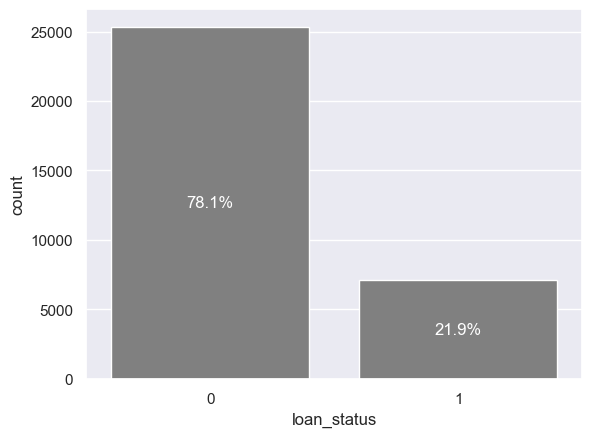

In [347]:
# target Y
plt.figure()
sns.countplot(data= df, x= 'loan_status', color= 'grey')
plt.gca().bar_label(plt.gca().containers[0], 
                    fmt=lambda x: f'{x/len(df):.1%}', 
                    label_type='center', 
                    color='white')
plt.show()
# we'll deal with this imbalance using smote-end technique

<h5 style="color:yellow", weight= "bold">Multi-variate Analysis</h5>

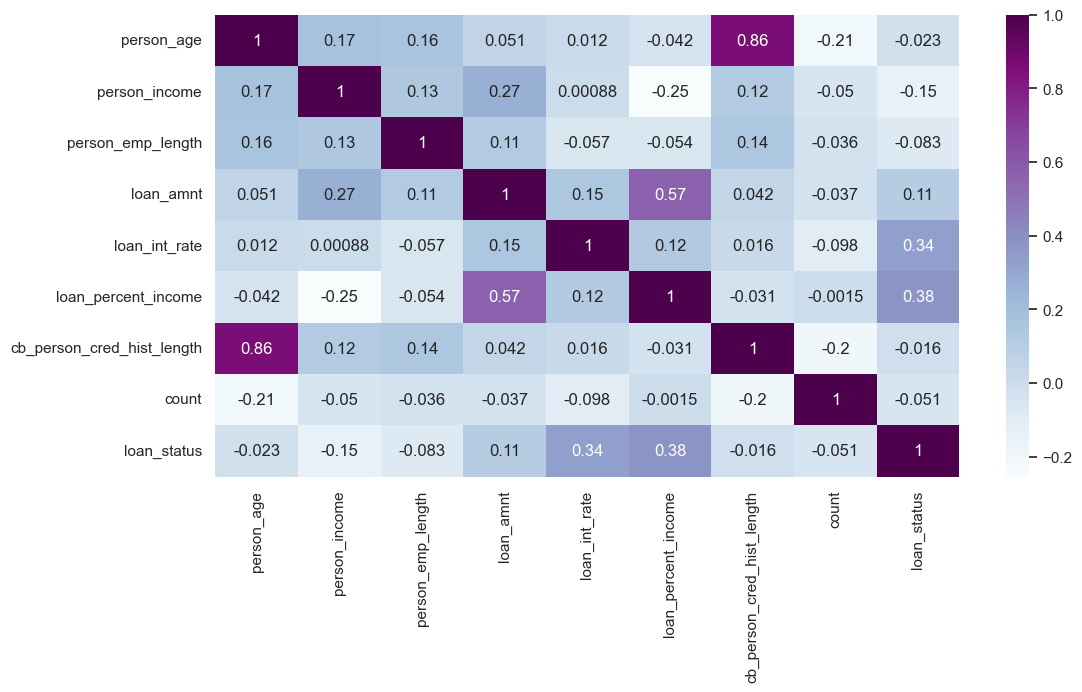

In [348]:
num_cols= df.select_dtypes(include='number')
plt.figure(figsize= (12, 6))
sns.heatmap(num_cols.corr(), cmap= 'BuPu', annot= True)
plt.show()

**Observing high correlation between 'cb_person_cred_hist_length / person_age', we'll drop the former later**

In [349]:
# plt.figure()
# sns.pairplot(num_cols, 
#              hue='loan_status', 
#              diag_kind='hist', 
#              palette={0: 'grey', 1: '#FFB6C1'},
#              plot_kws={'alpha': 0.5, 's': 20}) # S is dot size

# plt.show()

<h5 style="color:yellow", weight= "bold">Flagging-outliers</h5>

In [350]:
outliers_indices= []
outliers_indices.extend(df[df['person_age']>80].index)
outliers_indices.extend(df[df['person_emp_length']>30].index)
df= df.drop(outliers_indices)
df= df.reset_index(drop= True)

In [351]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,count,loan_status
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0.10,N,2,1,0
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.57,N,3,1,1
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,0.53,N,2,1,1
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,0.55,Y,4,1,1
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,0.25,N,2,1,1


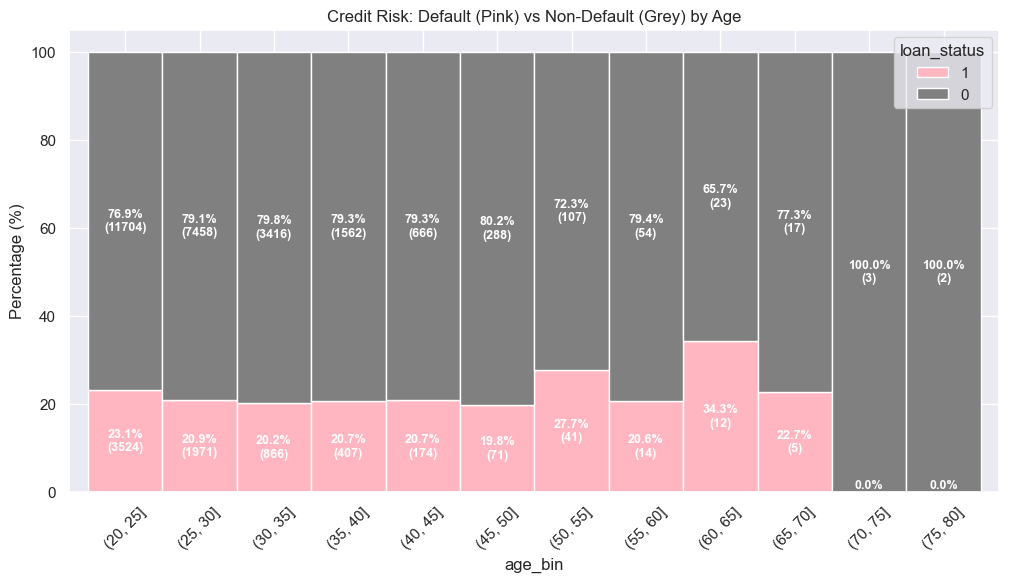

In [352]:
# 1. Bins and Dataframes (Percentages and Counts)
df['age_bin'] = pd.cut(df['person_age'], bins=range(20, int(df['person_age'].max()) + 6, 5))
pivot_pct = pd.crosstab(df['age_bin'], df['loan_status'], normalize='index')[[1, 0]] * 100
pivot_cnt = pd.crosstab(df['age_bin'], df['loan_status'])[[1, 0]]

plt.figure(figsize=(12, 6))
pivot_pct.plot(kind='bar', stacked=True, color=['#FFB6C1', 'grey'], width=1, ax=plt.gca())

# 2. Add labels using a loop to combine Pct and Count
for i, container in enumerate(plt.gca().containers):
    # Zip percentages from the plot with raw counts from our count table
    labels = [f'{p:.1f}%\n({c})' for p, c in zip(container.datavalues, pivot_cnt.iloc[:, i])]
    
    plt.gca().bar_label(container, labels=labels, label_type='center', 
                        color='white', fontweight='bold', fontsize=9)

plt.ylabel('Percentage (%)')
plt.title('Credit Risk: Default (Pink) vs Non-Default (Grey) by Age')
plt.xticks(rotation=45)
plt.show()

**no clear pattern linking age to default rates**

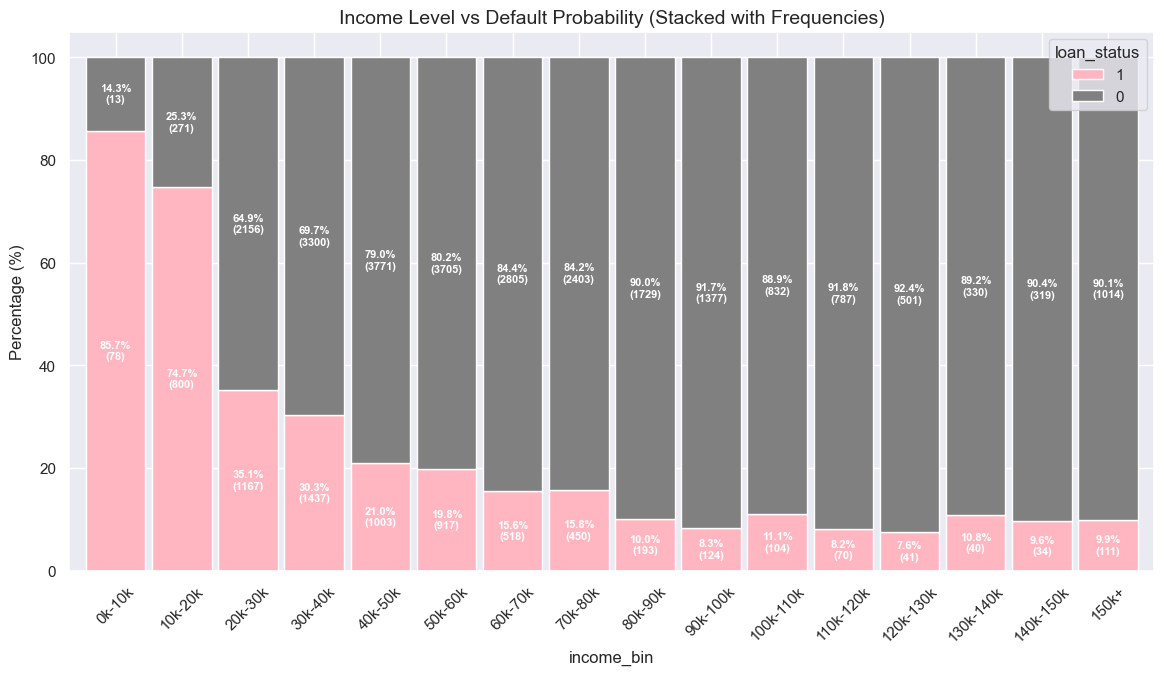

In [353]:
# 1. Bins and Labels
income_bins = list(range(0, 151001, 10000)) + [float('inf')]
income_labels = [f'{i//1000}k-{(i+10000)//1000}k' for i in range(0, 141000, 10000)] + ['150k+']
df['income_bin'] = pd.cut(df['person_income'], bins=income_bins, labels=income_labels)

# 2. Percentage and Count Tables
pivot_pct = pd.crosstab(df['income_bin'], df['loan_status'], normalize='index')[[1, 0]] * 100
pivot_cnt = pd.crosstab(df['income_bin'], df['loan_status'])[[1, 0]]

plt.figure(figsize=(14, 7))
pivot_pct.plot(kind='bar', stacked=True, color=['#FFB6C1', 'grey'], width=0.9, ax=plt.gca())

# 3. Combined Labels: Percentage + (Count)
for i, container in enumerate(plt.gca().containers):
    labels = [f'{p:.1f}%\n({c})' for p, c in zip(container.datavalues, pivot_cnt.iloc[:, i])]
    plt.gca().bar_label(container, labels=labels, label_type='center', 
                        color='white', fontweight='bold', fontsize=8)

plt.title('Income Level vs Default Probability (Stacked with Frequencies)', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.show()

**Individuals with low income show high default risk percentages, specifically those below 40k yearly income**

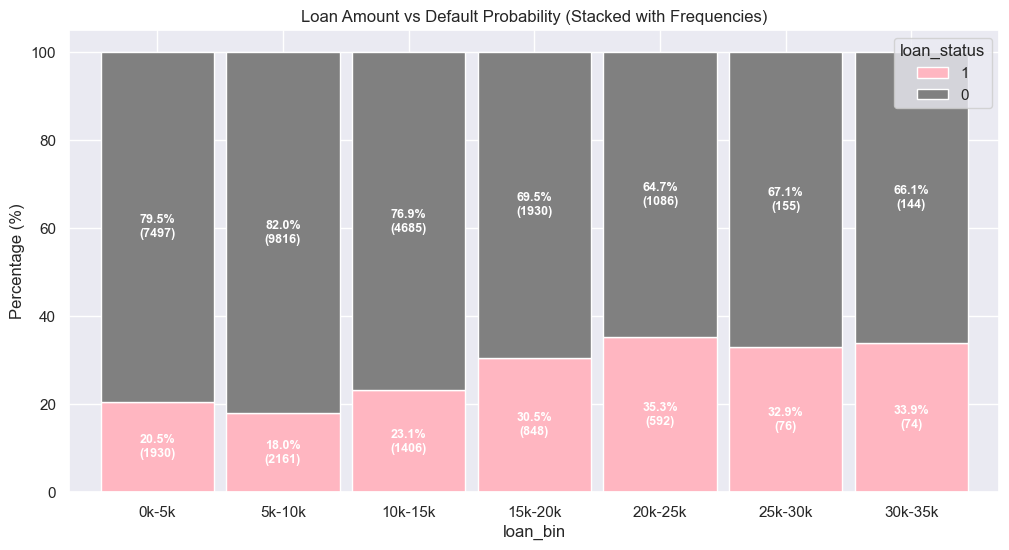

In [354]:
# 1. Binning
loan_bins = list(range(0, 35001, 5000))
loan_labels = [f'{i//1000}k-{(i+5000)//1000}k' for i in range(0, 35000, 5000)]
df['loan_bin'] = pd.cut(df['loan_amnt'], bins=loan_bins, labels=loan_labels)

# 2. Percentage and Count Dataframes
pivot_pct = pd.crosstab(df['loan_bin'], df['loan_status'], normalize='index')[[1, 0]] * 100
pivot_cnt = pd.crosstab(df['loan_bin'], df['loan_status'])[[1, 0]]

plt.figure(figsize=(12, 6))
pivot_pct.plot(kind='bar', stacked=True, color=['#FFB6C1', 'grey'], width=0.9, ax=plt.gca())

# 3. Combined Labels: % and (N)
for i, container in enumerate(plt.gca().containers):
    labels = [f'{p:.1f}%\n({c})' for p, c in zip(container.datavalues, pivot_cnt.iloc[:, i])]
    plt.gca().bar_label(container, labels=labels, label_type='center', 
                        color='white', fontweight='bold', fontsize=9)

plt.title('Loan Amount vs Default Probability (Stacked with Frequencies)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.show()

**loans above 15k hold higher percentages of defaults compared to lowers ones.**

In [355]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,count,loan_status,age_bin,income_bin,loan_bin
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0.10,N,2,1,0,"(20, 25]",0k-10k,0k-5k
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.57,N,3,1,1,"(20, 25]",0k-10k,5k-10k
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,0.53,N,2,1,1,"(20, 25]",60k-70k,30k-35k
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,0.55,Y,4,1,1,"(20, 25]",50k-60k,30k-35k
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,0.25,N,2,1,1,"(20, 25]",0k-10k,0k-5k


In [356]:
from IPython.display import display_html
high_loan_df = df[df['loan_amnt'] >= 15000]
grad_counts = high_loan_df['loan_grade'].value_counts().to_frame()
int_stats = high_loan_df['loan_int_rate'].describe().round(1).to_frame()

# 2. Style them to float left to right
df1_styler = grad_counts.style.set_table_attributes("style='display:inline; margin-right:20px;'").set_caption("Loan Grade Counts")
df2_styler = int_stats.style.set_table_attributes("style='display:inline; margin-right:20px;'").set_caption("Interest Rate Stats")
#age-bins loans holders abov 15k
age_frequencies= high_loan_df['person_age'].describe().round(1).to_frame()
#income bins of loan holders abov 15k
income_bin_frequencies= high_loan_df['income_bin'].value_counts().to_frame()
df3_style= age_frequencies.style.set_table_attributes("style='display:inline; margin-right:20px;'").set_caption('Age bins frequencies')
df4_style= income_bin_frequencies.style.set_table_attributes("style='display:inline;'").set_caption('income-bins frequencies')
# 3. Display
display_html(df1_styler._repr_html_() + df2_styler._repr_html_() + df3_style._repr_html_() + df4_style._repr_html_(), raw=True)

,count
loan_grade,
B,2359
A,1263
C,1242
D,966
E,409
F,122
G,40
,loan_int_rate
count,5813.000000


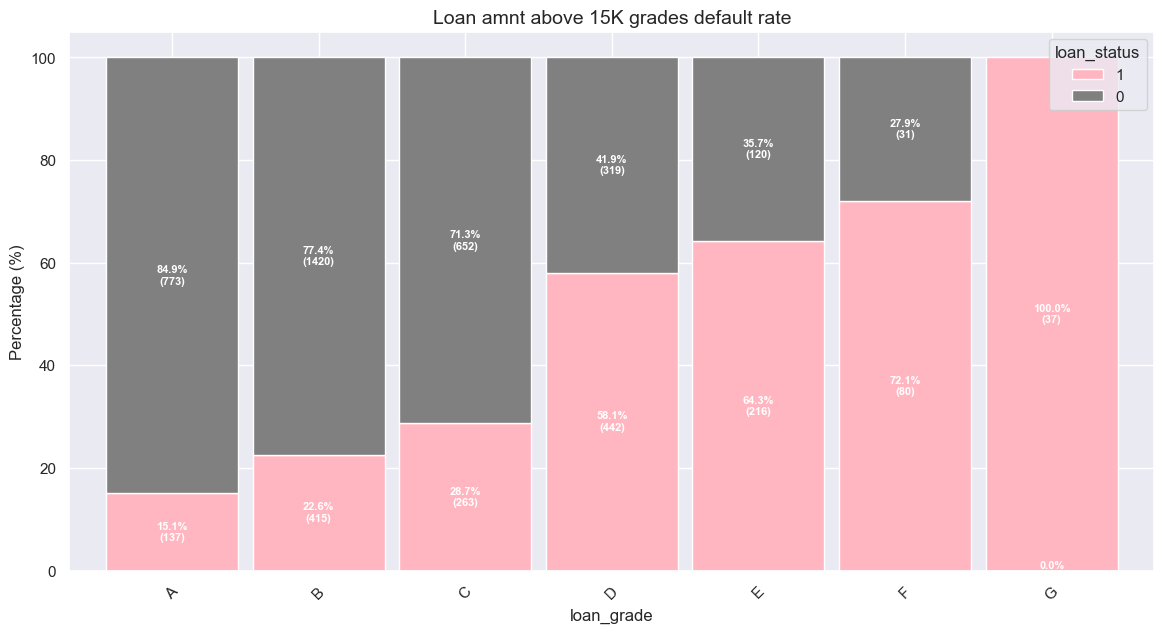

In [357]:
df_highloan= df[df['loan_amnt']>15000]
# 2. Percentage and Count Tables
pivot_pct = pd.crosstab(df_highloan['loan_grade'], df['loan_status'], normalize='index')[[1, 0]] * 100
pivot_cnt = pd.crosstab(df_highloan['loan_grade'], df['loan_status'])[[1, 0]]

plt.figure(figsize=(14, 7))
pivot_pct.plot(kind='bar', stacked=True, color=['#FFB6C1', 'grey'], width=0.9, ax=plt.gca())

# 3. Combined Labels: Percentage + (Count)
for i, container in enumerate(plt.gca().containers):
    labels = [f'{p:.1f}%\n({c})' for p, c in zip(container.datavalues, pivot_cnt.iloc[:, i])]
    plt.gca().bar_label(container, labels=labels, label_type='center', 
                        color='white', fontweight='bold', fontsize=8)

plt.title('Loan amnt above 15K grades default rate', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.show()

**it appears that bad loans are even worth looking into when the loan amnt exceeds 15k, (we cannot ignore them, due to evidence of high default rates).**

In [358]:
# are higher loan amount / interest rates increase the default probability.


int_rate_default = df[df['loan_status']== 1]['loan_int_rate'].describe().round(1).to_frame()
int_rate_non_default = df[df['loan_status']==0]['loan_int_rate'].describe().round(1).to_frame()

# 2. Style them to float left to right
df1_styler = int_rate_default.style.set_table_attributes("style='display:inline; margin-right:20px;'").set_caption("int_rate_default")
df2_styler = int_rate_non_default.style.set_table_attributes("style='display:inline;'").set_caption("int_rate_non_default")

display_html(df1_styler._repr_html_() + df2_styler._repr_html_(), raw=True)

,loan_int_rate
count,6446.000000
mean,13.100000
std,3.300000
min,5.400000
25%,10.700000
50%,13.500000
75%,15.600000
max,23.200000
,loan_int_rate
count,22861.000000


In [359]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'count', 'loan_status', 'age_bin',
       'income_bin', 'loan_bin'],
      dtype='object')

**clearly high interest rates are linked to high default rates**

In [360]:
# do people with stable jobs default less.

job_default = df[df['loan_status']== 1]['person_emp_length'].describe().round(1).to_frame()
job_non_default = df[df['loan_status']==0]['person_emp_length'].describe().round(1).to_frame()

# 2. Style them to float left to right
df1_styler = job_default.style.set_table_attributes("style='display:inline; margin-right:20px;'").set_caption("job_default")
df2_styler = job_non_default.style.set_table_attributes("style='display:inline;'").set_caption("job_non_default")

display_html(df1_styler._repr_html_() + df2_styler._repr_html_(), raw=True)

,person_emp_length
count,6806.000000
mean,4.100000
std,3.900000
min,0.000000
25%,1.000000
50%,3.000000
75%,6.000000
max,30.000000
,person_emp_length
count,24707.000000


**strong correlation showing unstable jobs linked with high default rates**

## Handling Outliers

In [361]:
data= data.drop(outliers_indices)
data= data.reset_index(drop= True)
new_cols_2= [cols for cols in data.columns if cols != 'loan_status'] + ['loan_status']
data= data[new_cols_2]

## Feature Engineering

In [362]:
# features_to_add: age-bin, income-bin, loan_bin, count(loan_count_per-person_at a time),
def engineer_features(eng_data):
    flag_cols= ['person_age', 'person_income', 'person_home_ownership','person_emp_length',
                       'cb_person_default_on_file', 'cb_person_cred_hist_length']
    eng_data['count']= eng_data.groupby(flag_cols, dropna= False)['person_age'].transform('count')
    bins_income= list(range(0, 151_000, 10_000)) + [float('inf')]
    labels_income= [f'{i//1000}k-{(i+10_000)//1000}k' for i in range(0, 141_000, 10_000)] + ['150k+']
    eng_data['income_bin']= pd.cut(eng_data['person_income'], bins= bins_income, labels= labels_income)
    bins_age= list(range(20, 146, 5))
    labels_age= [f'{i}-{i+5}' for i in range(20, 141, 5)]
    eng_data['age_bin']= pd.cut(eng_data['person_age'],bins= bins_age, labels= labels_age)
    bins_loan= list(range(0, 35_001, 5_000))
    labels_loan= [f'{i//1000}k-{(i+5000)//1000}k' for i in range(0, 35_000, 5_000)]
    eng_data['loan_bin']= pd.cut(eng_data['loan_amnt'], bins= bins_loan, labels= labels_loan)
    return eng_data

## Preprocessing

**Splitting the data**

In [363]:
data= data.dropna()

In [364]:
data.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [365]:
from sklearn.model_selection import train_test_split as tts
inputs= data.drop('loan_status', axis= 1)
target= data[['loan_status']]
x_train, x_test, y_train, y_test= tts(inputs, target, test_size= .2, random_state= 22, stratify= target)

**locating categorical and object column indicies**

In [366]:
alfa_engineered = engineer_features(inputs.head())
categorical_cols= alfa_engineered.select_dtypes(include= ['object','category']).columns


# 2. Get indices based on the ACTUAL columns present at that step
cat_obj_indicies = [i for i, col in enumerate(alfa_engineered.columns) 
                    if col in categorical_cols]

C:\Users\mmopa\AppData\Local\Temp\ipykernel_2004\4289338027.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eng_data['count']= eng_data.groupby(flag_cols, dropna= False)['person_age'].transform('count')
C:\Users\mmopa\AppData\Local\Temp\ipykernel_2004\4289338027.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eng_data['income_bin']= pd.cut(eng_data['person_income'], bins= bins_income, labels= labels_income)
C:\Users\mmopa\AppData\Local\Temp\ipykernel_2004\4289338027.py:11: SettingWithCopyWarning: 
A

In [367]:
onehot_cols= ['person_home_ownership','loan_intent','cb_person_default_on_file']
ordinal_cols= ['age_bin','loan_grade','income_bin','loan_bin']
numerical_cols= alfa.select_dtypes(include= 'number').drop(['cb_person_cred_hist_length','loan_status'], axis= 1).columns

In [368]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

In [369]:
num_pipe= Pipeline([
    ('num_imputer', SimpleImputer(strategy= 'median')),
    ('std',StandardScaler())
])
ohe_pipe= Pipeline([
    ('oh_imputer', SimpleImputer(strategy= 'most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown= 'ignore')),
])
ord_pipe= Pipeline([
    ('ord_imputer',SimpleImputer(strategy='most_frequent')),
    ('ord',OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
preprossesor= ColumnTransformer([
    ('num_ops', num_pipe, numerical_cols),
    ('ohe_ops', ohe_pipe, onehot_cols),
    ('ord_ops',ord_pipe,ordinal_cols)
])
full_pipe= ImbPipeline([
    ('f-e_transform', FunctionTransformer(engineer_features)),
    ('smotenc', SMOTENC(categorical_features= cat_obj_indicies, random_state= 22)),
    ('preprocessor', preprossesor)
])

## Model Selection

In [370]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [371]:
xgb_pipe= ImbPipeline(full_pipe.steps + [('xgboost',XGBClassifier())])
lgb_pipe= ImbPipeline(full_pipe.steps + [('lgbm', LGBMClassifier())])

## Model Tunning

In [372]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

In [373]:
xgb_params = {
    'xgboost__n_estimators': [50, 100],
    'xgboost__max_depth': [3, 5],
    'xgboost__learning_rate': [0.01, 0.1]
}

lgb_params = {
    'lgbm__n_estimators': [50, 100],
    'lgbm__num_leaves': [15, 31],
    'lgbm__learning_rate': [0.01, 0.1]
}
# Search for XGBoost
xgb_search = RandomizedSearchCV(xgb_pipe, xgb_params, n_iter=5, scoring='f1', cv=3, random_state=22)
xgb_search.fit(x_train, y_train)

# Search for LightGBM
lgb_search = RandomizedSearchCV(lgb_pipe, lgb_params, n_iter=5, scoring='f1', cv=3, random_state=22)
lgb_search.fit(x_train, y_train)

# Predictions using the best models
xgb_best = xgb_search.best_estimator_
lgb_best = lgb_search.best_estimator_

y_pred_xgb = xgb_best.predict(x_test)
y_pred_lgb = lgb_best.predict(x_test)

# Results collection
results = {
    'XGBoost': accuracy_score(y_test, y_pred_xgb),
    'LightGBM': accuracy_score(y_test, y_pred_lgb)
}
sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ),

C:\Users\mmopa\AppData\Local\Temp\ipykernel_2004\3796654544.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=values, ax=ax[0], palette='viridis')


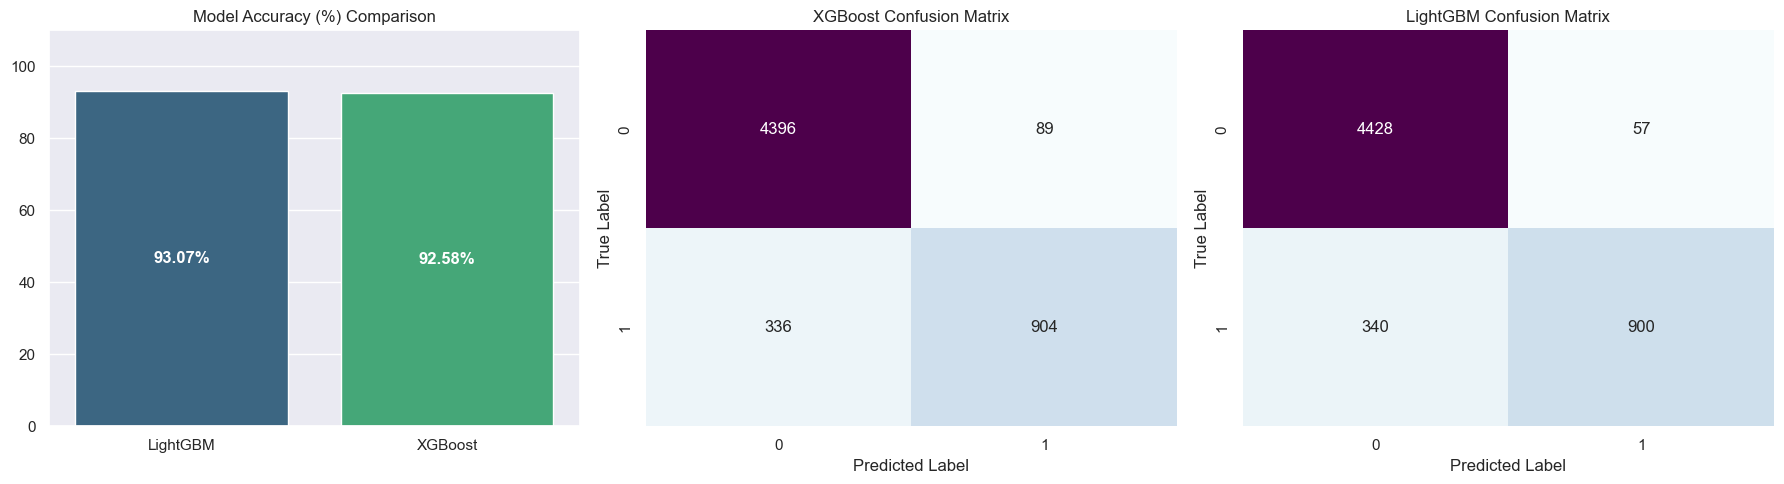

In [374]:
results = {
    'XGBoost': accuracy_score(y_test, y_pred_xgb),
    'LightGBM': accuracy_score(y_test, y_pred_lgb)
}
sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

# 2. Initialize 1x3 Figure
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Accuracy Bar Plot ---
# Multiply by 100 for percentage display
names = list(sorted_results.keys())
values = [v * 100 for v in sorted_results.values()]

sns.barplot(x=names, y=values, ax=ax[0], palette='viridis')

# Explicitly label every bar in the container
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='%.2f%%', label_type='center', 
                    color='white', weight='bold', fontsize=12)

ax[0].set_title('Model Accuracy (%) Comparison')
ax[0].set_ylim(0, 110) # Set to 110 to give headroom

# --- Plot 2: XGBoost Confusion Matrix ---
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', 
            cmap='BuPu', ax=ax[1], cbar=False)
ax[1].set_title('XGBoost Confusion Matrix')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')

# --- Plot 3: LightGBM Confusion Matrix ---
sns.heatmap(confusion_matrix(y_test, y_pred_lgb), annot=True, fmt='d', 
            cmap='BuPu', ax=ax[2], cbar=False)
ax[2].set_title('LightGBM Confusion Matrix')
ax[2].set_xlabel('Predicted Label')
ax[2].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [375]:
# Print best parameters for both models
print("--- Best XGBoost Parameters ---")
print(xgb_search.best_params_)

print("\n--- Best LightGBM Parameters ---")
print(lgb_search.best_params_)

--- Best XGBoost Parameters ---
{'xgboost__n_estimators': 100, 'xgboost__max_depth': 5, 'xgboost__learning_rate': 0.1}

--- Best LightGBM Parameters ---
{'lgbm__num_leaves': 31, 'lgbm__n_estimators': 100, 'lgbm__learning_rate': 0.1}


In [376]:
from sklearn.model_selection import GridSearchCV

# Narrow, focused grids
xgb_grid = {
    'xgboost__n_estimators': [100, 150],
    'xgboost__max_depth': [5, 6],
    'xgboost__learning_rate': [0.1, 0.15]
}

lgb_grid = {
    'lgbm__n_estimators': [100, 150],
    'lgbm__num_leaves': [31, 45],
    'lgbm__learning_rate': [0.1, 0.15]
}

# Using GridSearchCV for exhaustive search in this small space
xgb_gs = GridSearchCV(xgb_pipe, xgb_grid, scoring='f1', cv=3)
lgb_gs = GridSearchCV(lgb_pipe, lgb_grid, scoring='f1', cv=3)

xgb_gs.fit(x_train, y_train)
lgb_gs.fit(x_train, y_train)

# Predictions
y_pred_xgb_gs = xgb_gs.best_estimator_.predict(x_test)
y_pred_lgb_gs = lgb_gs.best_estimator_.predict(x_test)

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ),

C:\Users\mmopa\AppData\Local\Temp\ipykernel_2004\4196037110.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sorted_gs.keys()), y=[v * 100 for v in sorted_gs.values()], ax=ax[0], palette='magma')


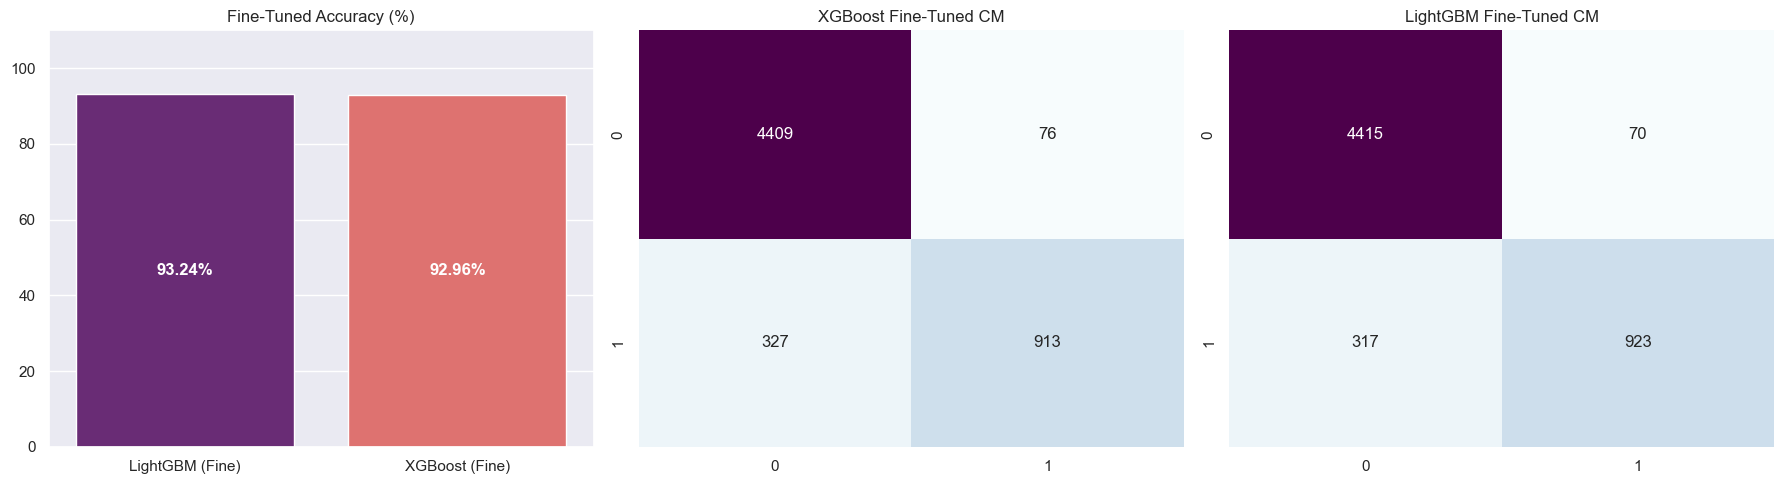

In [377]:
results_gs = {
    'XGBoost (Fine)': accuracy_score(y_test, y_pred_xgb_gs),
    'LightGBM (Fine)': accuracy_score(y_test, y_pred_lgb_gs)
}
sorted_gs = dict(sorted(results_gs.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Accuracy
sns.barplot(x=list(sorted_gs.keys()), y=[v * 100 for v in sorted_gs.values()], ax=ax[0], palette='magma')
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='%.2f%%', label_type='center', color='white', weight='bold')
ax[0].set_title('Fine-Tuned Accuracy (%)')
ax[0].set_ylim(0, 110)

# Plot 2: XGBoost Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_xgb_gs), annot=True, fmt='d', cmap='BuPu', ax=ax[1], cbar=False)
ax[1].set_title('XGBoost Fine-Tuned CM')

# Plot 3: LightGBM Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lgb_gs), annot=True, fmt='d', cmap='BuPu', ax=ax[2], cbar=False)
ax[2].set_title('LightGBM Fine-Tuned CM')

plt.tight_layout()
plt.show()

In [378]:
# 1. Extract the best hyperparameters from the search
best_lgbm_params = lgb_gs.best_params_

# 2. Re-instantiate the pipeline with these parameters
# We use the full 'inputs' and 'target' variables (the entire data)
final_lgbm_pipe = lgb_gs.best_estimator_

# 3. Final training on all available data
final_lgbm_pipe.fit(inputs, target)

print("Final LightGBM model training complete on the full dataset.")

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Final LightGBM model training complete on the full dataset.


In [381]:
# things to add:
# model-inference using third-party tools for xgboost/lgbm
# stratifiedKfold grid-search to shuffle the data
# pie charts for categorical data
# learning-curves / to check model training hyper space performance.
# more on metrics and metrics optimization.
# more on feature engineering.
# more on IterativeImputer.